In this case study, we will implement hierarchical risk parity based on clustering
methods and compare it against other portfolio allocation methods. The case study is based on the paper _“Building Diversified Portfolios that Outperform Out-ofSample” (2016) by Marcos Lopez de Prado._ 



## Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Libraries and Dataset](#1)
    * [2.1. Load Libraries](#1.1)    
    * [2.2. Load Dataset](#1.2)
* [3. Exploratory Data Analysis](#2)
    * [3.1 Descriptive Statistics](#2.1)    
    * [3.2. Data Visualisation](#2.2)
* [4. Data Preparation](#3)
    * [4.1 Data Cleaning](#3.1)
    * [4.3.Data Transformation](#3.2)  
* [5.Evaluate Algorithms and Models](#4)        
    * [5.1. Building Hierarchy Graph/ Dendogramg](#4.1)
    * [5.2. Steps for Hierarchial Risk Parity](#4.2)
* [6.Backtesting-Out Of Sample ](#5)  

<a id='0'></a>
# 1. Problem Definition

Our goal in this case study is to maximize risk-adjusted returns using a clustering
reduction-based algorithm on a dataset of stocks to allocate capital into different asset
classes. 

<a id='1'></a>
# 2. Getting Started- Loading the data and python packages

<a id='1.1'></a>
## 2.1. Loading the python packages

Checking is the additional packages needed are present, if not install them. Let us chek is the cvxopt package is present, if not install it. This package is checked separately as it is not included in requirement.txt of this book repository as the package is not used across any other case study of thie book.

In [58]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import date

#Import Model Packages 
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from sklearn.metrics import adjusted_mutual_info_score
from sklearn import cluster, covariance, manifold

#Package for optimization of mean variance optimization
import cvxopt as opt
from cvxopt import blas, solvers


<a id='1.2'></a>
## 2.2. Loading the Data

In [59]:
# load dataset
dataset = read_csv('SP500Data.csv',index_col=0)

In [60]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

In [61]:
type(dataset)

pandas.core.frame.DataFrame

<a id='2'></a>
# 3. Exploratory Data Analysis

<a id='2.1'></a>
## 3.1. Descriptive Statistics

In [62]:
# shape
dataset.shape

(448, 502)

In [63]:
# peek at data
set_option('display.width', 100)
dataset.head(5)

,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,58.790001,98.410004,192.490005,153.839996,64.309998,177.699997,10.98,106.089996,10.88,203.039993,...,146.990005,164.300003,47.810001,29.370001,67.879997,68.070000,81.599998,124.059998,50.700001,71.769997
2018-01-03,58.919998,99.949997,195.820007,154.550003,65.309998,181.039993,11.55,107.050003,10.87,202.119995,...,149.740005,162.520004,47.490002,29.330000,69.239998,68.900002,81.529999,124.919998,50.639999,72.099998
2018-01-04,58.820000,99.379997,199.250000,156.380005,64.660004,183.220001,12.12,111.000000,10.83,198.539993,...,151.259995,163.399994,47.119999,29.690001,70.489998,69.360001,82.360001,124.739998,50.849998,72.529999
2018-01-05,58.990002,101.110001,202.320007,157.669998,66.370003,185.339996,11.88,112.180000,10.87,199.470001,...,152.229996,164.490005,46.790001,29.910000,74.150002,69.230003,82.839996,125.980003,50.869999,73.360001
2018-01-08,58.820000,99.489998,207.800003,158.929993,66.629997,185.039993,12.28,111.389999,10.87,200.529999,...,151.410004,162.300003,47.139999,30.260000,74.639999,69.480003,82.980003,126.220001,50.619999,74.239998


<a id='2.2'></a>
## 3.2. Data Visualization

We will look at the data visualisation in the later sections.

<a id='3'></a>
## 4. Data Preparation

<a id='3.1'></a>
## 4.1. Data Cleaning
We check for the NAs in the rows, either drop them or fill them with the mean of the column.

In [64]:
#Checking for any null values and removing the null values'''
print('Null Values =',dataset.isnull().values.any())
dataset.shape

Null Values = True


(448, 502)

Getting rid of the columns with more than 30% missing values. 

In [65]:
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)

missing_fractions.head(10)

drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))

dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(448, 498)

Given that there are null values drop the rown contianing the null values.

In [66]:
# Fill the missing values with the last value available in the dataset. 
dataset=dataset.fillna(method='ffill')
dataset.head(2)

,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,58.790001,98.410004,192.490005,153.839996,64.309998,177.699997,10.98,106.089996,10.88,203.039993,...,146.990005,164.300003,47.810001,29.370001,67.879997,68.070000,81.599998,124.059998,50.700001,71.769997
2018-01-03,58.919998,99.949997,195.820007,154.550003,65.309998,181.039993,11.55,107.050003,10.87,202.119995,...,149.740005,162.520004,47.490002,29.330000,69.239998,68.900002,81.529999,124.919998,50.639999,72.099998


<a id='3.2'></a>
## 4.2. Data Transformation

For the purpose of clustering, we will be using annual
returns. Additionally, we will train the data followed by testing. Let us prepare the
dataset for training and testing, by separating 20% of the dataset for testing followed
by generating the return series.

In [67]:
X= dataset.copy('deep')
row= len(X)
train_len = int(row*.8)

In [68]:
X_train = X.head(train_len)
X_test = X.tail(row-train_len)

In [69]:
#Calculate percentage return 
returns = X_train.pct_change().dropna()
returns_test=X_test.pct_change().dropna()

The parameters to clusters are the indices and the variables used in the clustering are the columns. Hence the data is in the right format to be fed to the clustering algorithms

<a id='4'></a>
# 5. Evaluate Algorithms and Models

<a id='4.1'></a>
## 5.1. Building Hierarchy Graph/ Dendogram

The first step is to look for clusters of corre‐
lations using the agglomerate hierarchical clustering technique. The hierarchy class
has a dendrogram method which takes the value returned by the linkage method of
the same class.

Linkage does the actual clustering in one line of code, and returns a list of the clusters joined in the format: Z=[stock_1, stock_2, distance, sample_count]

#### Compute Correlation

In [70]:
def correlDist(corr):
    # A distance matrix based on correlation, where 0<=d[i,j]<=1
    # This is a proper distance metric
    dist = ((1 - corr) / 2.)**.5  # distance matrix
    return dist

In [71]:
#Calulate linkage
dist = correlDist(returns.corr())
link = linkage(dist, 'ward')
link[0]

array([24.        , 25.        ,  0.09110116,  2.        ])

Computation of linkages is followed by
the visualization of the clusters through a dendrogram, which displays a cluster tree.
The leaves are the individual stocks and the root is the final single cluster. The “distance” between each cluster is shown on the y-axis, and thus the longer the branches
are, the less correlated two clusters are.

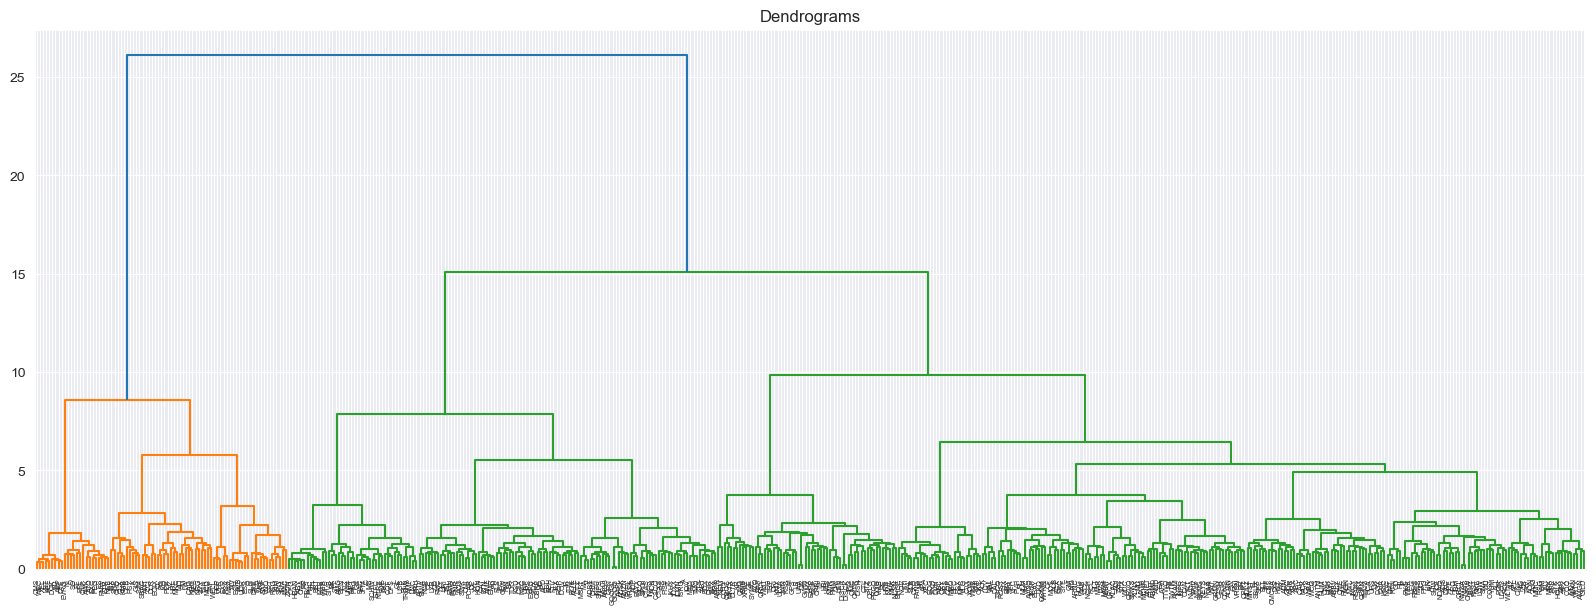

In [72]:
#Plot Dendogram
plt.figure(figsize=(20, 7))
plt.title("Dendrograms")
dendrogram(link,labels = X.columns)
plt.show()

<a id='4.2'></a>
## 5.2 Steps for Hierarchial Risk Parity

#### Quasi-diagonalization and getting the weights for Hierarchial Risk Parity


A 'quasi-diagonalization' is a process usually known as matrix seriation and which can be performed using hierarchical clustering.
This process reorganize the covariance matrix so similar investments will be placed together. This matrix diagonalization allow us to distribute weights optimally following an inverse-variance allocation.

In [73]:
def getQuasiDiag(link):
    # Sort clustered items by distance
    link = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3]  # number of original items
    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0] * 2, 2)  # make space
        df0 = sortIx[sortIx >= numItems]  # find clusters
        i = df0.index
        j = df0.values - numItems
        sortIx[i] = link[j, 0]  # item 1
        df0 = pd.Series(link[j, 1], index=i + 1)  # item 2
        sortIx = pd.concat([sortIx, df0])  # <-- remplacement ici
        sortIx = sortIx.sort_index()  # re-sort
        sortIx.index = range(sortIx.shape[0])  # re-index
    return sortIx.tolist()

#### Recursive bisection

 This step distributes the allocation through recursive bisection based on cluster covariance.

In [74]:
def getClusterVar(cov,cItems):
    # Compute variance per cluster
    cov_=cov.loc[cItems,cItems] # matrix slice
    w_=getIVP(cov_).reshape(-1,1)
    cVar=np.dot(np.dot(w_.T,cov_),w_)[0,0]
    return cVar

def getRecBipart(cov: pd.DataFrame, sortIx: list) -> pd.Series:
    """
    Calcule les poids HRP (Hierarchical Risk Parity) par allocation récursive binaire.

    Parameters:
        cov (pd.DataFrame): Matrice de covariance.
        sortIx (list): Ordre quasi-diagonal des actifs (issu de getQuasiDiag).

    Returns:
        pd.Series: Poids HRP indexés par les actifs.
    """
    w = pd.Series(1.0, index=sortIx)  # Initialisation des poids
    cItems = [sortIx]  # Tous les actifs dans un seul cluster au départ

    while cItems:
        # Division binaire de chaque cluster contenant plus d'un actif
        newClusters = [
            i[j:k] for i in cItems for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1
        ]
        cItems = newClusters

        for i in range(0, len(cItems), 2):  # Itération deux par deux
            cItems0 = cItems[i]
            cItems1 = cItems[i + 1]

            cVar0 = getClusterVar(cov, cItems0)
            cVar1 = getClusterVar(cov, cItems1)
            alpha = 1 - cVar0 / (cVar0 + cVar1)

            w[cItems0] *= alpha
            w[cItems1] *= 1 - alpha

    return w

#### Comparison against other asset allocation methods:.

The main premise of this case study
was to develop an alternative to Markowitz’s Minimum-Variance Portfolio based
asset allocation. So, in this step, we define a functions to compare the performance of the following asset allocation methods.

    1. MVP - Markowitz’s Minimum-Variance Portfolio
    2. HRP - Hierarchial Risk Parity

In [75]:


from cvxopt import matrix as mtx, solvers, blas
import numpy as np

def getMVP(cov: np.ndarray) -> list:
    """
    Calcule le Minimum Variance Portfolio (MVP) à l’aide de la programmation quadratique (cvxopt).

    Parameters:
        cov (np.ndarray or pd.DataFrame): Matrice de covariance des rendements.

    Returns:
        list: Poids optimaux du portefeuille MVP.
    """
    # Si l'entrée est une DataFrame, convertir en array
    if hasattr(cov, "values"):
        cov = cov.values

    n = cov.shape[0]
    N = 100
    mus = [10 ** (5.0 * t / N - 1.0) for t in range(N)]

    # cvxopt format
    S = mtx(cov)
    pbar = mtx(np.ones(n))  # on suppose un vecteur de rendements égaux

    # Contraintes : x >= 0, somme(x) = 1
    G = -mtx(np.eye(n))
    h = mtx(0.0, (n, 1))
    A = mtx(1.0, (1, n))
    b = mtx(1.0)

    # Désactiver l'affichage cvxopt
    solvers.options['show_progress'] = False

    # Frontière efficiente : calcul des portefeuilles
    portfolios = [solvers.qp(mu * S, -pbar, G, h, A, b)['x'] for mu in mus]
    returns = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S * x)) for x in portfolios]

    # Ajustement polynômial de degré 2
    coeffs = np.polyfit(returns, risks, 2)
    x1 = np.sqrt(coeffs[2] / coeffs[0])

    # Portefeuille optimal sur la frontière
    optimal_portfolio = solvers.qp(mtx(x1 * cov), -pbar, G, h, A, b)['x']
    return list(optimal_portfolio)


def getIVP(cov, **kargs):
    # Compute the inverse-variance portfolio
    ivp = 1. / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

def getHRP(cov, corr):
    # Construct a hierarchical portfolio
    dist = correlDist(corr)
    link = sch.linkage(dist, 'single')
    #plt.figure(figsize=(20, 10))
    #dn = sch.dendrogram(link, labels=cov.index.values)
    #plt.show()
    sortIx = getQuasiDiag(link)
    sortIx = corr.index[sortIx].tolist()
    hrp = getRecBipart(cov, sortIx)
    return hrp.sort_index()



#### Step 4:  Getting the portfolio weights for all types of asset allocation

In [76]:
def get_all_portfolios(returns):

    cov, corr = returns.cov(), returns.corr()
    hrp = getHRP(cov, corr)
    mvp = getMVP(cov)
    mvp = pd.Series(mvp, index=cov.index)
    portfolios = pd.DataFrame([mvp, hrp], index=['MVP', 'HRP']).T
    #portfolios = pd.DataFrame([ivp, hrp], index=['IVP', 'HRP']).T
    return portfolios

In [77]:
portfolios = get_all_portfolios(returns)

Text(0.5, 1.0, 'HRP')

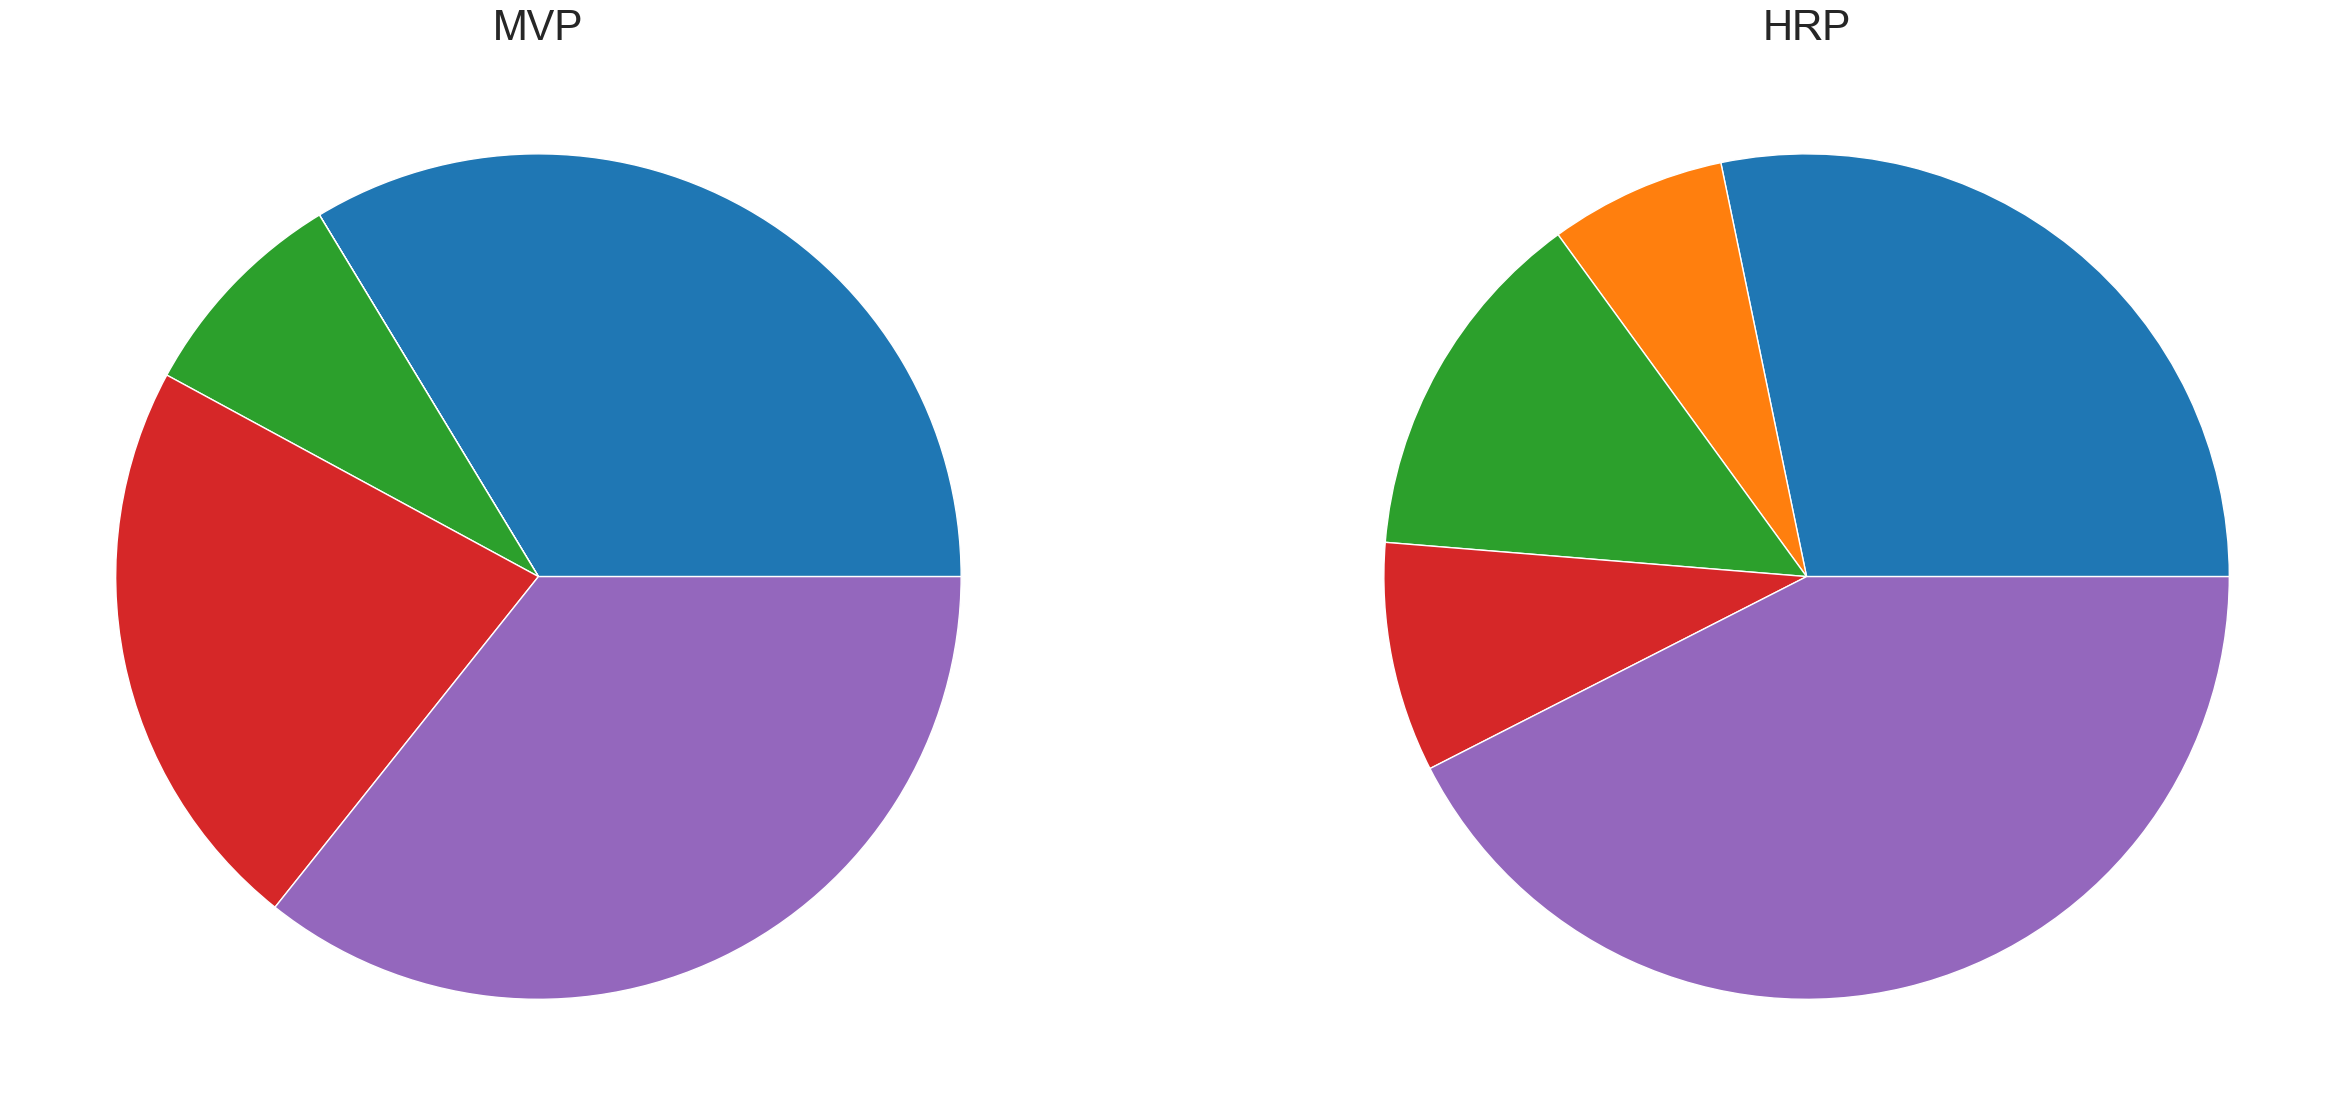

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(30,20))
ax1.pie(portfolios.iloc[:,0], );
ax1.set_title('MVP',fontsize = 30)
ax2.pie(portfolios.iloc[:,1]);
ax2.set_title('HRP',fontsize = 30)
#portfolios.plot.pie(subplots=True, figsize=(20, 10),legend = False);

The first pie chart shown the asset allocation of MVP, followed by IVP and HRP. We clearly see more diversification in HRP as compared to MVP. On the
other hand, IVP evenly spreads weights through all assets, and it looks similar to
HRP. However, this method ignores the correlation structure between the instruments unlike HRP is included just for comparison purpose. Let us look at the backtesting results.

<a id='5'></a>
# 6. Backtesting-Out Of Sample 

In [79]:
Insample_Result=pd.DataFrame(np.dot(returns,np.array(portfolios)), \
                             columns=['MVP', 'HRP'], index = returns.index)
OutOfSample_Result=pd.DataFrame(np.dot(returns_test,np.array(portfolios)), \
                                columns=['MVP', 'HRP'], index = returns_test.index)

<Axes: title={'center': 'Out Of Sample Results'}, xlabel='Date'>

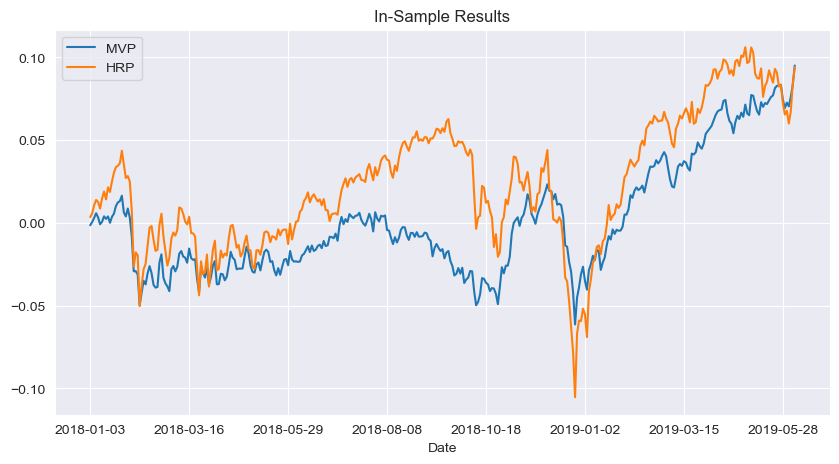

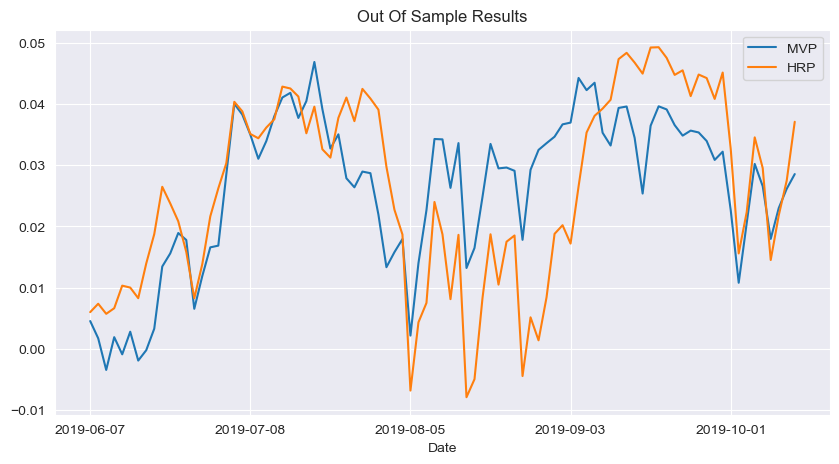

In [80]:
Insample_Result.cumsum().plot(figsize=(10, 5), title ="In-Sample Results")
OutOfSample_Result.cumsum().plot(figsize=(10, 5), title ="Out Of Sample Results")

### In Sample and Out of Sample Results

In [81]:
#In_sample Results
stddev = Insample_Result.std() * np.sqrt(252)
sharp_ratio = (Insample_Result.mean()*np.sqrt(252))/(Insample_Result).std()
Results = pd.DataFrame(dict(stdev=stddev, sharp_ratio = sharp_ratio))
Results

,stdev,sharp_ratio
MVP,0.085516,0.785019
HRP,0.126944,0.523599


In [82]:
#Outof_sample Results
stddev_oos = OutOfSample_Result.std() * np.sqrt(252)
sharp_ratio_oos = (OutOfSample_Result.mean()*np.sqrt(252))/(OutOfSample_Result).std()
Results_oos = pd.DataFrame(dict(stdev_oos=stddev_oos, sharp_ratio_oos = sharp_ratio_oos))
Results_oos

,stdev_oos,sharp_ratio_oos
MVP,0.102761,0.786621
HRP,0.125610,0.836159


Although the in-sample result of MVP look promising, the out of sample sharp ratio
and overall return of portfolio constructed using hierarchical clustering approach are
better. The diversification that HRP achieves across uncorrelated assets makes the
methodology more robust against shocks

**Conclusion**

Markowitz’s minimum-variance based portfolio allocation is less diverse and is concentrated in a few stocks. In the hierarchical clustering-based allocation, the allocation is more diverse and distributed across many assets. These portfolios then offer better tail risk management.

Finally, we looked at the backtesting framework, which enables us to compute and
analyze the in-sample and out of sample return and sharpe ratio of each hypothetical
portfolio. This helps in determining the best performer out of all the portfolio allocation methods. The hierarchical clustering approaches yielded the best out-of-sample
results.
